# Belauri Air Quality Sensor Data — Exploratory Data Analysis

**Location:** Belauri, Nepal  
**Sensors:** 4 devices (models 8143 and 8144)  
**Data period:** April 2025 – May 2026  

This notebook loads all available sensor data, characterises coverage and data quality, and produces preliminary visualisations of key pollutants.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

plt.rcParams.update({
    'figure.dpi': 150,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

DATA_ROOT = Path('/Users/yubraj/Code/air-quality-research/Data/Belauri')
print('Data root:', DATA_ROOT)

Data root: /Users/yubraj/Code/air-quality-research/Data/Belauri


## 1. Data Loading

Two file formats exist:
- **Periodic files** (`*-20XX-HX.csv`): detailed per-device exports with full column set and a units row.
- **Telemetry files** (`*_telemetry.csv`): narrow real-time dumps from the sensor firmware.

We load all periodic files (they have more complete sensor channels) and combine them into a single tidy dataframe.

In [2]:
# Core measurement columns we want (friendly names after renaming)
COL_MAP = {
    'Timestamp': 'timestamp',
    'Serial Number': 'serial',
    'Friendly Name': 'name',
    'Is Indoor': 'indoor',
    'Latitude': 'lat',
    'Longitude': 'lon',
    'PM2.5 AQI': 'pm25_aqi',
    'PM10 AQI': 'pm10_aqi',
    'PM1.0': 'pm1',
    'PM2.5': 'pm25',
    'PM4.0': 'pm4',
    'PM10': 'pm10',
    'PM0.5 NC': 'nc05',
    'PM1.0 NC': 'nc1',
    'PM2.5 NC': 'nc25',
    'PM4.0 NC': 'nc4',
    'PM10 NC': 'nc10',
    'Typical Particle Size': 'tps',
    'CO2': 'co2',
    'CH2O': 'ch2o',
    'CO': 'co',
    'SO2': 'so2',
    'O3': 'o3',
    'NO2': 'no2',
    'VOC tVOC measurement': 'tvoc',
    'Temperature': 'temp_c',
    'Relative Humidity': 'rh',
    'Barometric Pressure': 'baro_inhg',
    'PM Sensor Status': 'pm_status',
    'CO2 Sensor Status': 'co2_status',
    'System Status': 'sys_status',
}


def load_periodic(path: Path) -> pd.DataFrame:
    """Load a *-20XX-HX.csv file; row 1 is units, skip it."""
    df = pd.read_csv(path, skiprows=[1], low_memory=False)
    df = df.rename(columns={c: COL_MAP[c] for c in df.columns if c in COL_MAP})
    df['timestamp'] = pd.to_datetime(df['timestamp'], format='mixed', utc=True)
    # Keep only mapped columns that exist
    keep = [v for v in COL_MAP.values() if v in df.columns]
    return df[keep]


periodic_files = sorted(DATA_ROOT.rglob('*-20??-H?.csv'))
print(f'Found {len(periodic_files)} periodic files:')
for f in periodic_files:
    print(' ', f.relative_to(DATA_ROOT))

parts = []
for f in periodic_files:
    try:
        df = load_periodic(f)
        if len(df) > 2:   # skip empty stubs
            parts.append(df)
            print(f'  {f.name}: {len(df):,} rows, {df["timestamp"].min().date()} → {df["timestamp"].max().date()}')
        else:
            print(f'  {f.name}: SKIPPED (only {len(df)} rows)')
    except Exception as e:
        print(f'  {f.name}: ERROR — {e}')

all_df = pd.concat(parts, ignore_index=True).drop_duplicates(subset=['timestamp', 'serial'])
all_df = all_df.sort_values(['serial', 'timestamp']).reset_index(drop=True)
print(f'\nCombined: {len(all_df):,} rows, {all_df["serial"].nunique()} sensors')

Found 11 periodic files:
  81432434001-2025-H2.csv
  81432434001-2026-H1.csv
  81442326017-81442406076-81442410021/81442326017-2025-H1.csv
  81442326017-81442406076-81442410021/81442326017-2025-H2.csv
  81442326017-81442406076-81442410021/81442326017-2026-H1.csv
  81442326017-81442406076-81442410021/81442406076-2025-H1.csv
  81442326017-81442406076-81442410021/81442406076-2025-H2.csv
  81442326017-81442406076-81442410021/81442406076-2026-H1.csv
  81442326017-81442406076-81442410021/81442410021-2025-H1.csv
  81442326017-81442406076-81442410021/81442410021-2025-H2.csv
  81442326017-81442406076-81442410021/81442410021-2026-H1.csv


  81432434001-2025-H2.csv: 163,128 rows, 2025-07-01 → 2025-12-31


  81432434001-2026-H1.csv: 128,460 rows, 2026-01-01 → 2026-04-02
  81442326017-2025-H1.csv: SKIPPED (only 0 rows)
  81442326017-2025-H2.csv: 762 rows, 2025-11-24 → 2025-12-04
  81442326017-2026-H1.csv: 4,683 rows, 2026-01-05 → 2026-04-01
  81442406076-2025-H1.csv: SKIPPED (only 0 rows)


  81442406076-2025-H2.csv: 39,075 rows, 2025-11-24 → 2025-12-31


  81442406076-2026-H1.csv: 128,113 rows, 2026-01-01 → 2026-04-01


  81442410021-2025-H1.csv: 42,586 rows, 2025-04-24 → 2025-06-17


  81442410021-2025-H2.csv: 232,053 rows, 2025-07-23 → 2025-12-31


  81442410021-2026-H1.csv: 101,542 rows, 2026-01-01 → 2026-04-01



Combined: 840,401 rows, 4 sensors


## 2. Sensor Inventory

In [3]:
inventory = all_df.groupby('serial').agg(
    name=('name', 'first'),
    indoor=('indoor', 'first'),
    start=('timestamp', 'min'),
    end=('timestamp', 'max'),
    n_obs=('timestamp', 'count'),
).reset_index()
inventory['duration_days'] = (inventory['end'] - inventory['start']).dt.days
inventory['start'] = inventory['start'].dt.date
inventory['end'] = inventory['end'].dt.date
display(inventory)

,serial,name,indoor,start,end,n_obs,duration_days
0,81432434001,BS-14,False,2025-07-01,2026-04-02,291588,275
1,81442326017,Indoor 03,True,2025-11-24,2026-04-01,5445,127
2,81442406076,Cynthia's House,True,2025-11-24,2026-04-01,167188,128
3,81442410021,AA-1,True,2025-04-24,2026-04-01,376180,342


## 3. Data Coverage Timeline

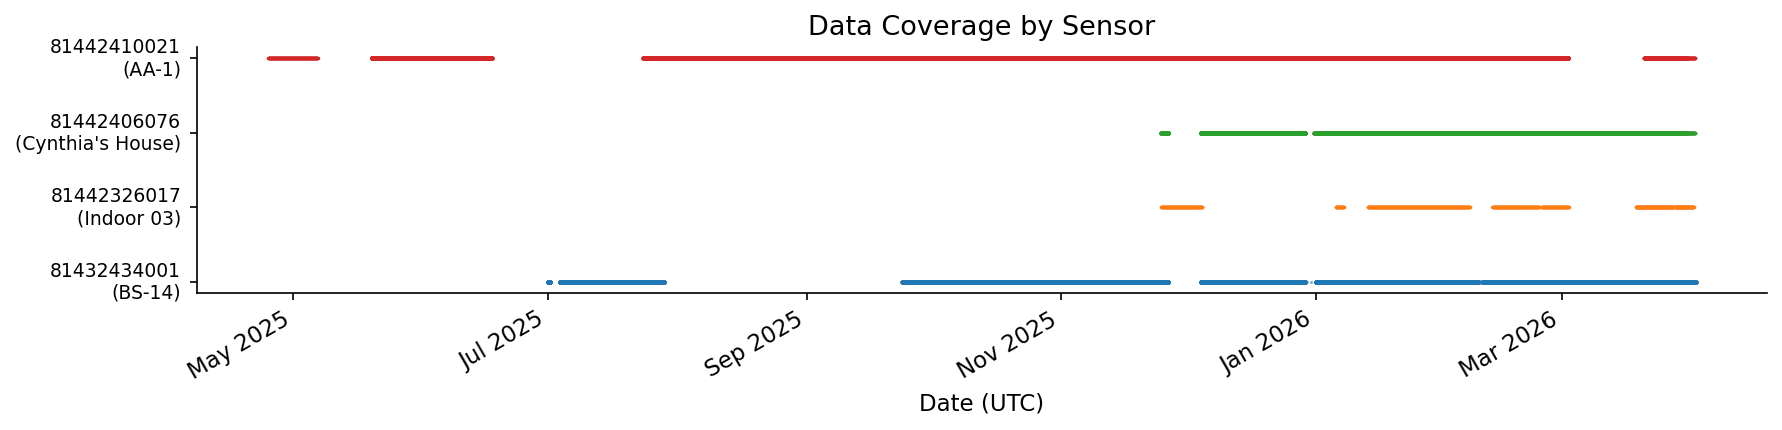

In [4]:
fig, ax = plt.subplots(figsize=(12, 3))

colors = plt.cm.tab10.colors
serials = sorted(all_df['serial'].unique())

for i, serial in enumerate(serials):
    sub = all_df[all_df['serial'] == serial]
    ax.scatter(sub['timestamp'], [i] * len(sub), s=0.3, color=colors[i], alpha=0.5, rasterized=True)
    label = f"{serial}\n({sub['name'].iloc[0]})"
    ax.text(-0.01, i, label, ha='right', va='center', transform=ax.get_yaxis_transform(), fontsize=9)

ax.set_yticks(range(len(serials)))
ax.set_yticklabels(['' ] * len(serials))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.setp(ax.get_xticklabels(), rotation=30, ha='right')
ax.set_title('Data Coverage by Sensor')
ax.set_xlabel('Date (UTC)')
plt.tight_layout()
plt.show()

## 4. Missing-Data Summary

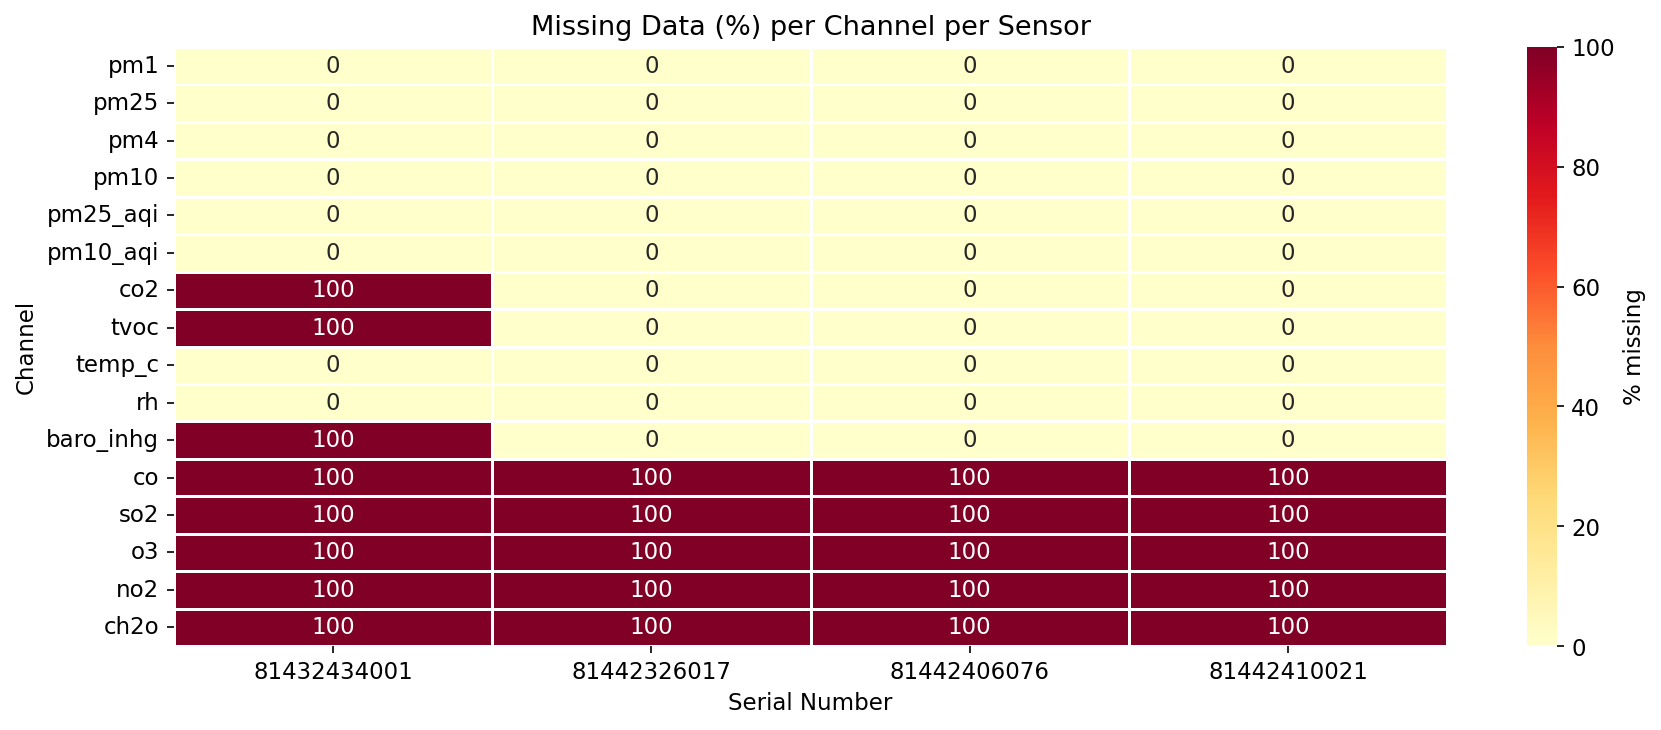

In [5]:
measure_cols = ['pm1','pm25','pm4','pm10','pm25_aqi','pm10_aqi',
                'co2','tvoc','temp_c','rh','baro_inhg','co','so2','o3','no2','ch2o']
measure_cols = [c for c in measure_cols if c in all_df.columns]

def pct_missing(s):
    try:
        s = pd.to_numeric(s, errors='coerce')
    except Exception:
        pass
    return s.isna().mean() * 100

miss = all_df.groupby('serial')[measure_cols].apply(lambda g: g.apply(pct_missing)).T
miss.columns = [str(c) for c in miss.columns]

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(miss, annot=True, fmt='.0f', cmap='YlOrRd', vmin=0, vmax=100,
            linewidths=0.5, ax=ax, cbar_kws={'label': '% missing'})
ax.set_title('Missing Data (%) per Channel per Sensor')
ax.set_xlabel('Serial Number')
ax.set_ylabel('Channel')
plt.tight_layout()
plt.show()

## 5. Particulate Matter Time Series

PM2.5 (µg/m³) is the primary health-relevant metric. We plot hourly-resampled medians per sensor.

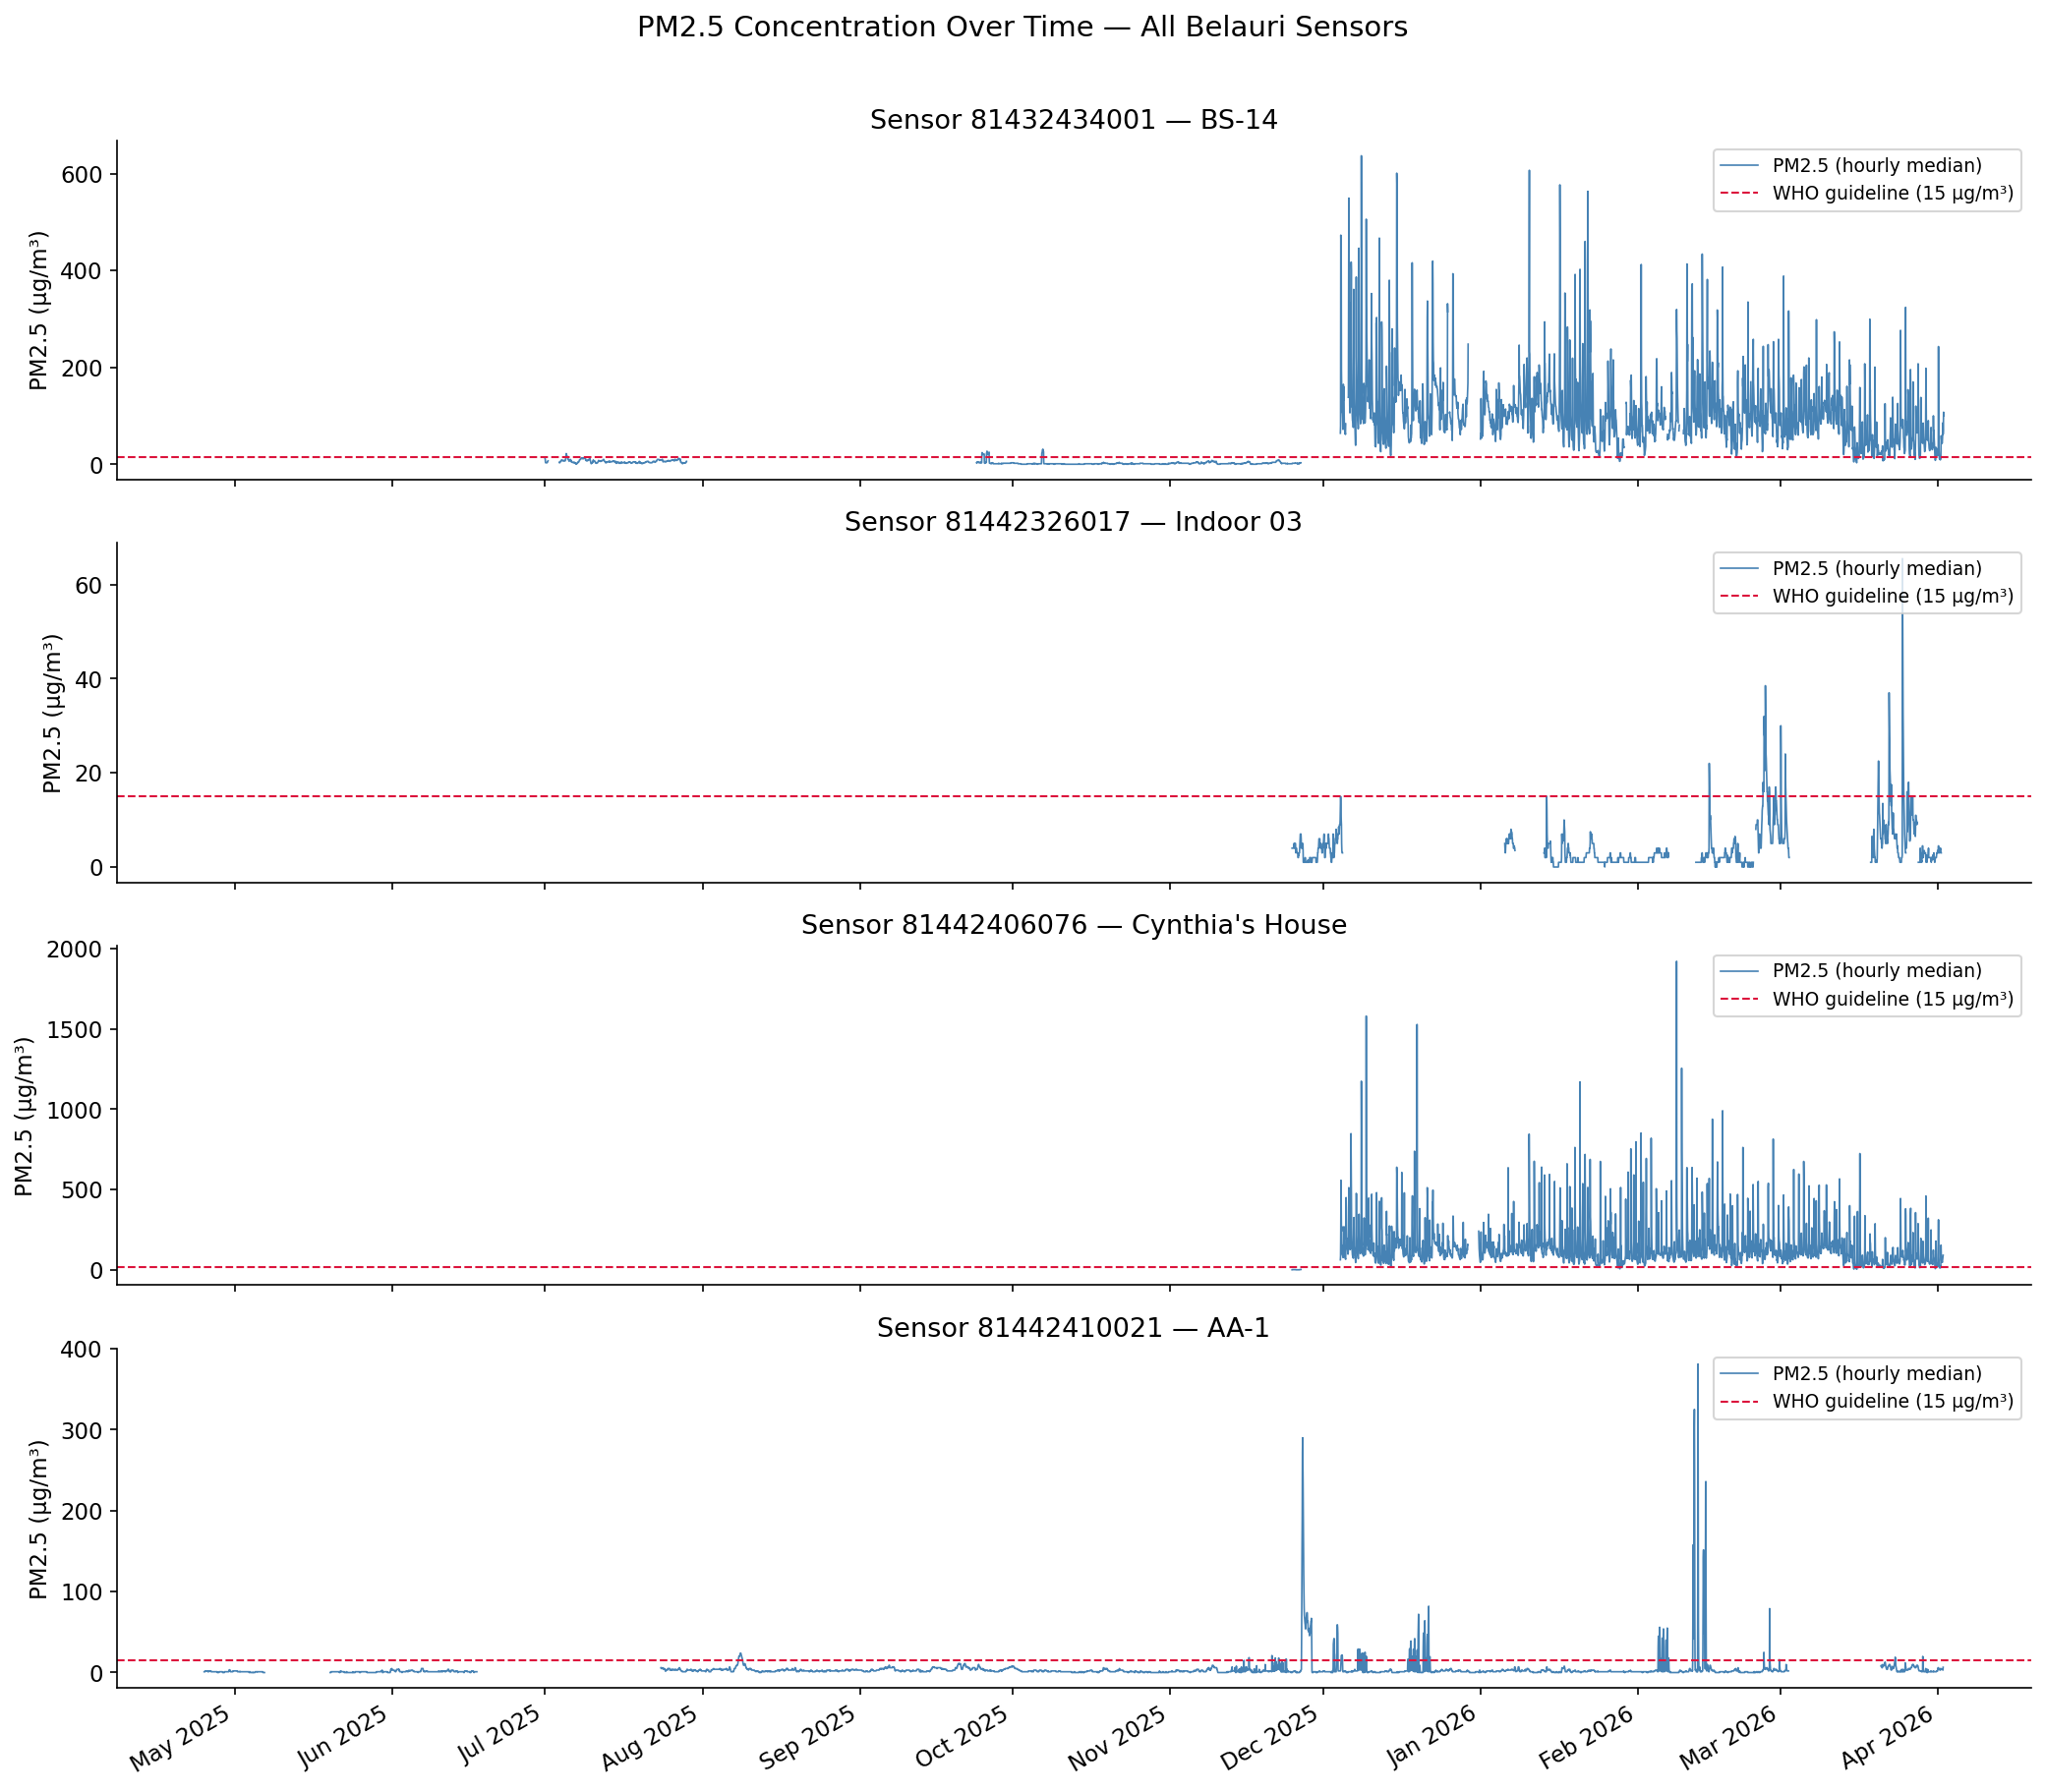

In [6]:
fig, axes = plt.subplots(len(serials), 1, figsize=(14, 3 * len(serials)), sharex=True)
if len(serials) == 1:
    axes = [axes]

WHO_PM25 = 15   # WHO 2021 annual guideline µg/m³

for ax, serial in zip(axes, serials):
    sub = all_df[all_df['serial'] == serial].set_index('timestamp')
    pm = pd.to_numeric(sub['pm25'], errors='coerce').resample('1h').median()
    ax.plot(pm.index, pm.values, lw=0.8, color='steelblue', label='PM2.5 (hourly median)')
    ax.axhline(WHO_PM25, color='crimson', lw=1, ls='--', label=f'WHO guideline ({WHO_PM25} µg/m³)')
    sensor_name = sub['name'].iloc[0] if 'name' in sub.columns else serial
    ax.set_ylabel('PM2.5 (µg/m³)')
    ax.set_title(f'Sensor {serial} — {sensor_name}')
    ax.legend(loc='upper right', fontsize=9)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[-1].xaxis.set_major_locator(mdates.MonthLocator(interval=1))
plt.setp(axes[-1].get_xticklabels(), rotation=30, ha='right')
fig.suptitle('PM2.5 Concentration Over Time — All Belauri Sensors', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 6. PM Size Fractions (PM1 / PM2.5 / PM10)

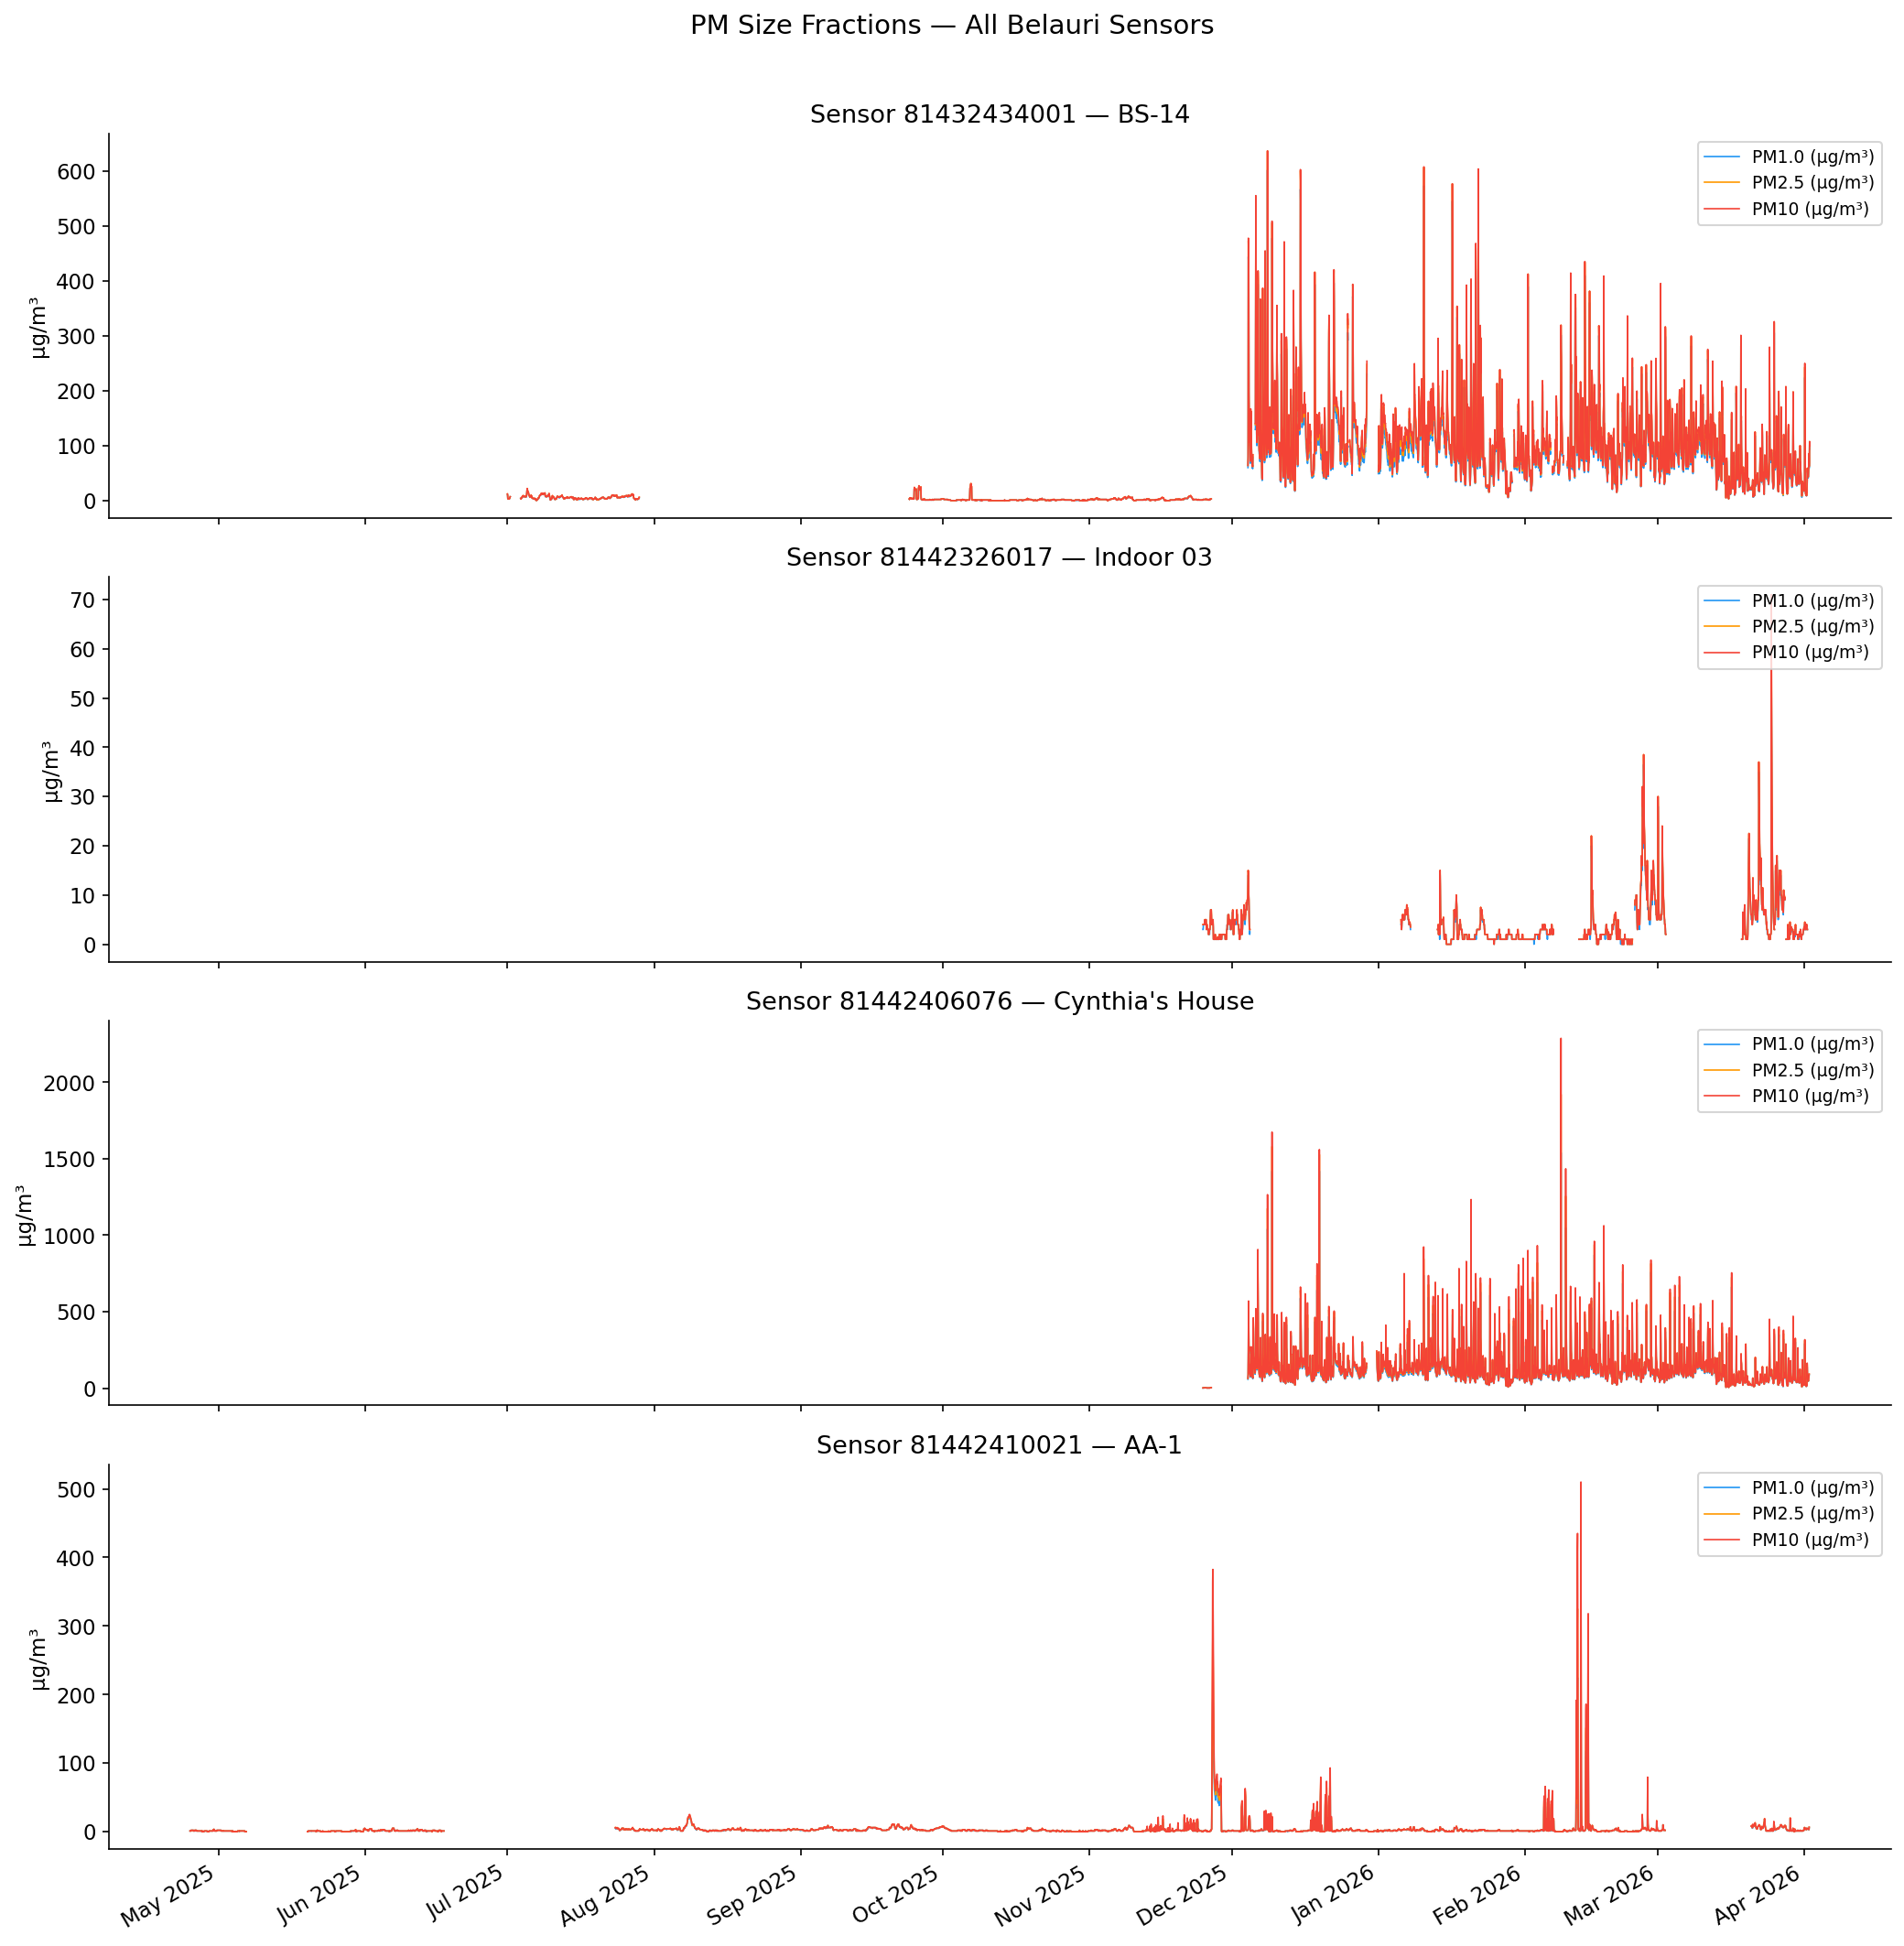

In [7]:
fig, axes = plt.subplots(len(serials), 1, figsize=(14, 3.5 * len(serials)), sharex=True)
if len(serials) == 1:
    axes = [axes]

PM_COLS = {'pm1': 'PM1.0', 'pm25': 'PM2.5', 'pm10': 'PM10'}
PM_COLORS = {'pm1': '#2196F3', 'pm25': '#FF9800', 'pm10': '#F44336'}

for ax, serial in zip(axes, serials):
    sub = all_df[all_df['serial'] == serial].set_index('timestamp')
    for col, label in PM_COLS.items():
        if col in sub.columns:
            s = pd.to_numeric(sub[col], errors='coerce').resample('1h').median()
            ax.plot(s.index, s.values, lw=0.8, label=f'{label} (µg/m³)', color=PM_COLORS[col])
    sensor_name = sub['name'].iloc[0] if 'name' in sub.columns else serial
    ax.set_ylabel('µg/m³')
    ax.set_title(f'Sensor {serial} — {sensor_name}')
    ax.legend(loc='upper right', fontsize=9)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[-1].xaxis.set_major_locator(mdates.MonthLocator(interval=1))
plt.setp(axes[-1].get_xticklabels(), rotation=30, ha='right')
fig.suptitle('PM Size Fractions — All Belauri Sensors', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 7. AQI Distribution

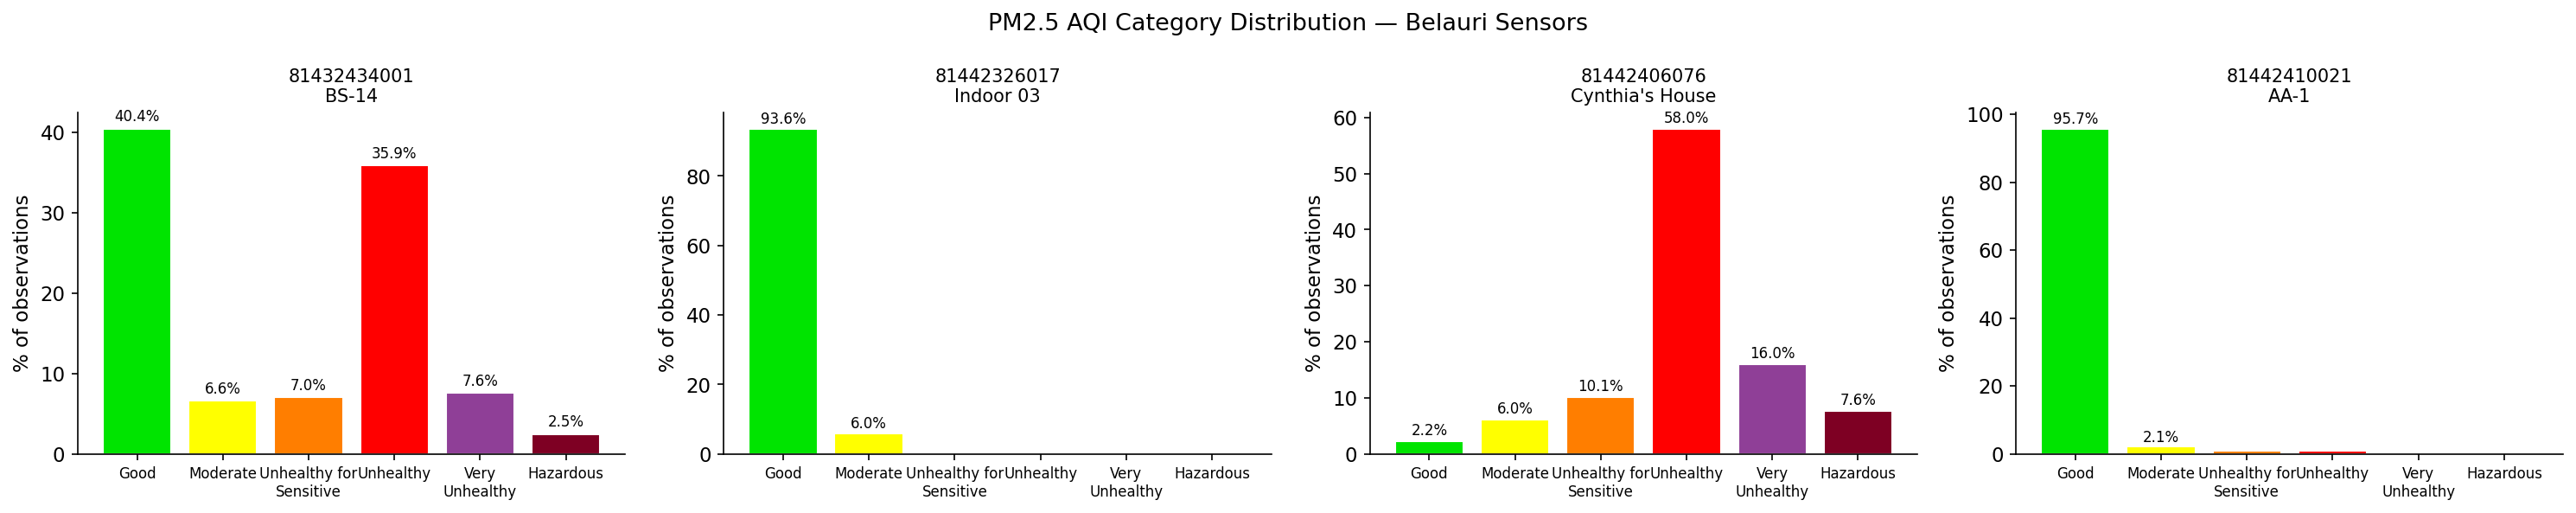

In [8]:
AQI_BREAKS = [0, 50, 100, 150, 200, 300, 500]
AQI_LABELS = ['Good', 'Moderate', 'Unhealthy for\nSensitive', 'Unhealthy', 'Very\nUnhealthy', 'Hazardous']
AQI_COLORS = ['#00e400', '#ffff00', '#ff7e00', '#ff0000', '#8f3f97', '#7e0023']

fig, axes = plt.subplots(1, len(serials), figsize=(5 * len(serials), 4), sharey=False)
if len(serials) == 1:
    axes = [axes]

for ax, serial in zip(axes, serials):
    sub = all_df[all_df['serial'] == serial]
    aqi = pd.to_numeric(sub['pm25_aqi'], errors='coerce').dropna()
    cats = pd.cut(aqi, bins=AQI_BREAKS, labels=AQI_LABELS, right=True)
    counts = cats.value_counts().reindex(AQI_LABELS).fillna(0)
    pct = counts / counts.sum() * 100

    bars = ax.bar(range(len(AQI_LABELS)), pct.values, color=AQI_COLORS, edgecolor='white', width=0.8)
    ax.set_xticks(range(len(AQI_LABELS)))
    ax.set_xticklabels(AQI_LABELS, fontsize=8)
    ax.set_ylabel('% of observations')
    sensor_name = sub['name'].iloc[0] if 'name' in sub.columns else serial
    ax.set_title(f'{serial}\n{sensor_name}', fontsize=10)
    for bar, val in zip(bars, pct.values):
        if val > 1:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                    f'{val:.1f}%', ha='center', va='bottom', fontsize=8)

fig.suptitle('PM2.5 AQI Category Distribution — Belauri Sensors', fontsize=13)
plt.tight_layout()
plt.show()

## 8. Diurnal (Hour-of-Day) Patterns

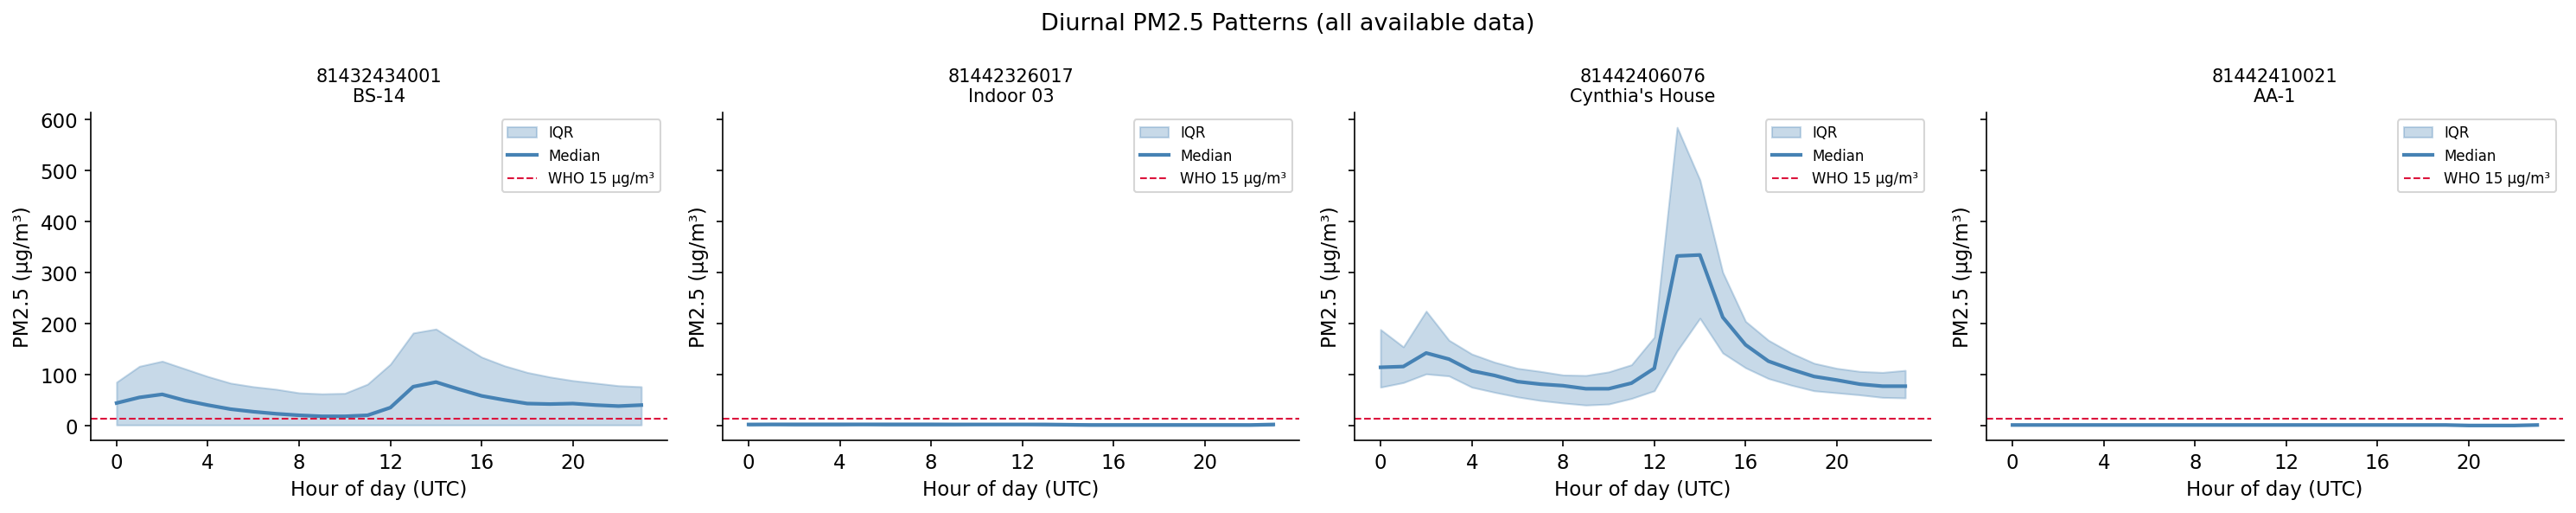

In [9]:
fig, axes = plt.subplots(1, len(serials), figsize=(5 * len(serials), 4), sharey=True)
if len(serials) == 1:
    axes = [axes]

for ax, serial in zip(axes, serials):
    sub = all_df[all_df['serial'] == serial].copy()
    sub['hour'] = sub['timestamp'].dt.hour
    sub['pm25'] = pd.to_numeric(sub['pm25'], errors='coerce')
    hourly = sub.groupby('hour')['pm25'].agg(['median', lambda x: x.quantile(0.25), lambda x: x.quantile(0.75)])
    hourly.columns = ['median', 'q25', 'q75']

    ax.fill_between(hourly.index, hourly['q25'], hourly['q75'], alpha=0.3, color='steelblue', label='IQR')
    ax.plot(hourly.index, hourly['median'], color='steelblue', lw=2, label='Median')
    ax.axhline(WHO_PM25, color='crimson', lw=1, ls='--', label=f'WHO {WHO_PM25} µg/m³')
    sensor_name = sub['name'].iloc[0] if 'name' in sub.columns else serial
    ax.set_xlabel('Hour of day (UTC)')
    ax.set_ylabel('PM2.5 (µg/m³)')
    ax.set_title(f'{serial}\n{sensor_name}', fontsize=10)
    ax.set_xticks(range(0, 24, 4))
    ax.legend(fontsize=8)

fig.suptitle('Diurnal PM2.5 Patterns (all available data)', fontsize=13)
plt.tight_layout()
plt.show()

## 9. CO2 Time Series (where available)

CO2 sensors are present on model-8144 devices (serials 81442326017, 81442406076, 81442410021).

Sensors with CO2 data: [81442326017, 81442406076, 81442410021]


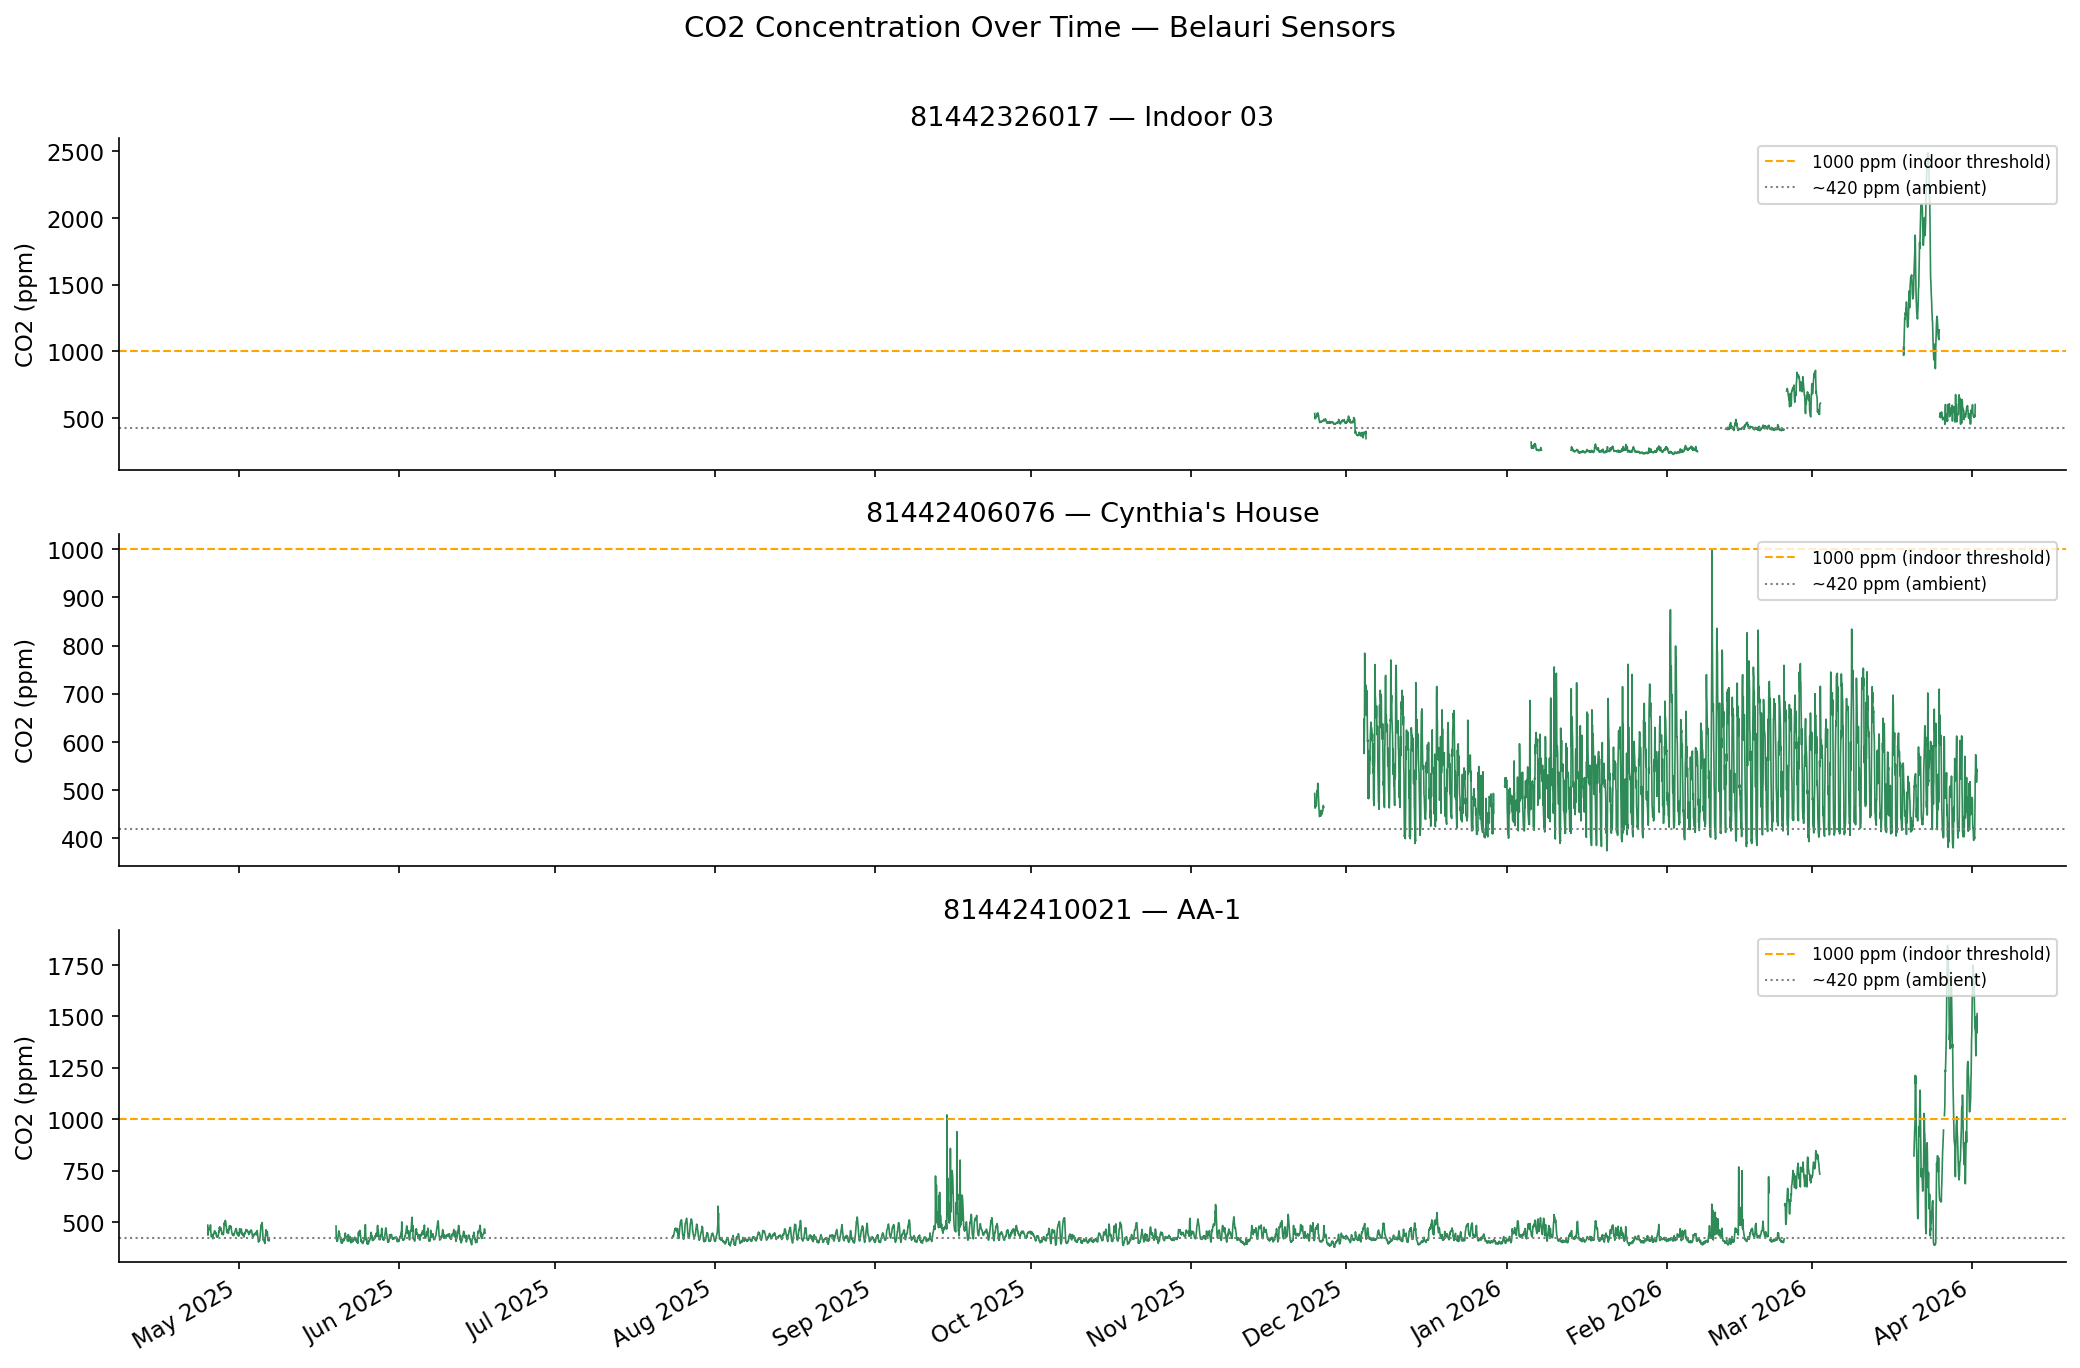

In [10]:
co2_serials = all_df.groupby('serial')['co2'].apply(lambda s: pd.to_numeric(s, errors='coerce').notna().sum())
co2_serials = co2_serials[co2_serials > 0].index.tolist()
print('Sensors with CO2 data:', co2_serials)

if co2_serials:
    fig, axes = plt.subplots(len(co2_serials), 1, figsize=(14, 3 * len(co2_serials)), sharex=True)
    if len(co2_serials) == 1:
        axes = [axes]

    for ax, serial in zip(axes, co2_serials):
        sub = all_df[all_df['serial'] == serial].set_index('timestamp')
        co2 = pd.to_numeric(sub['co2'], errors='coerce').resample('1h').median()
        ax.plot(co2.index, co2.values, lw=0.8, color='seagreen')
        ax.axhline(1000, color='orange', lw=1, ls='--', label='1000 ppm (indoor threshold)')
        ax.axhline(420, color='gray', lw=1, ls=':', label='~420 ppm (ambient)')
        sensor_name = sub['name'].iloc[0] if 'name' in sub.columns else serial
        ax.set_ylabel('CO2 (ppm)')
        ax.set_title(f'{serial} — {sensor_name}')
        ax.legend(fontsize=8, loc='upper right')

    axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    axes[-1].xaxis.set_major_locator(mdates.MonthLocator(interval=1))
    plt.setp(axes[-1].get_xticklabels(), rotation=30, ha='right')
    fig.suptitle('CO2 Concentration Over Time — Belauri Sensors', fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()
else:
    print('No CO2 data available.')

## 10. Temperature & Relative Humidity

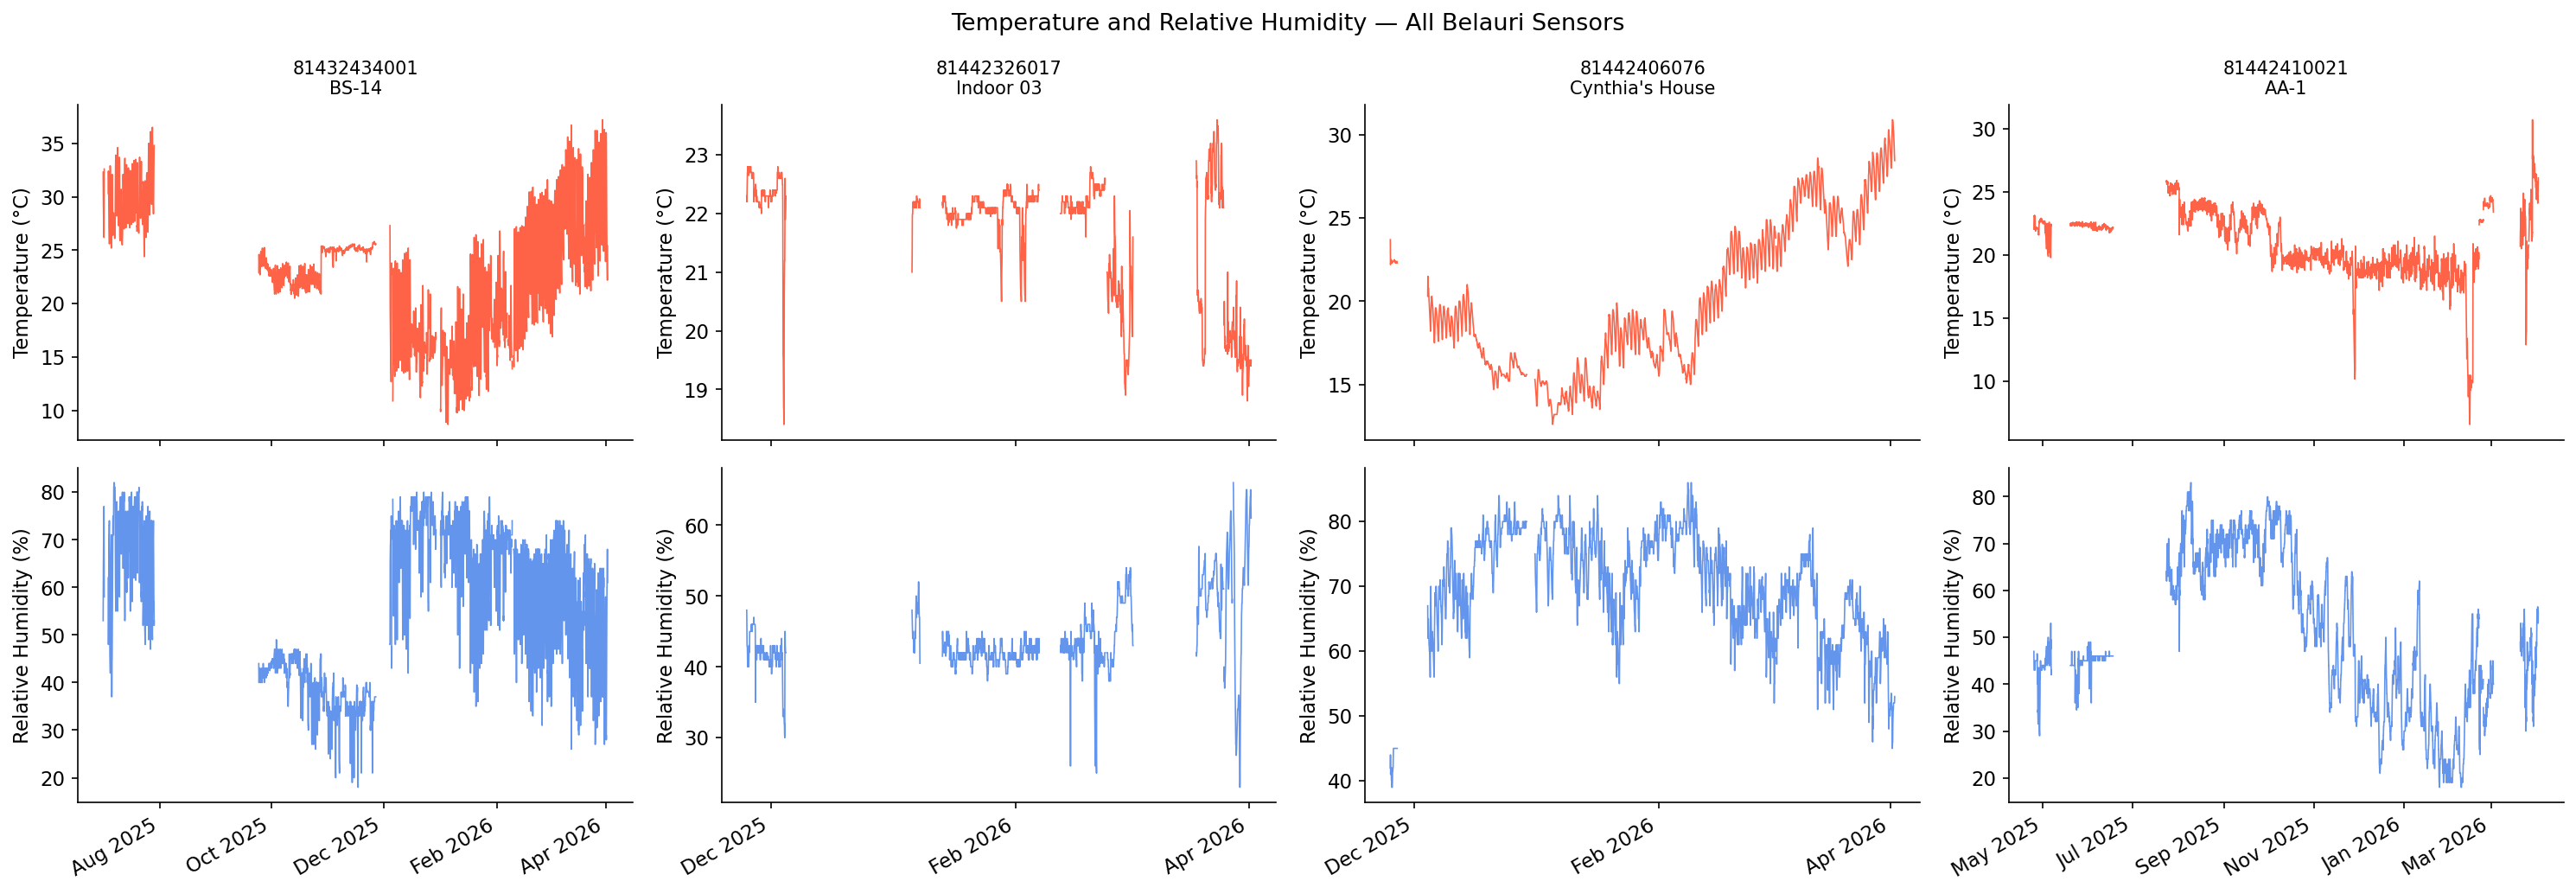

In [11]:
fig, axes = plt.subplots(2, len(serials), figsize=(5 * len(serials), 7), sharex='col')
if len(serials) == 1:
    axes = axes.reshape(2, 1)

for j, serial in enumerate(serials):
    sub = all_df[all_df['serial'] == serial].set_index('timestamp')
    sensor_name = sub['name'].iloc[0] if 'name' in sub.columns else serial

    temp = pd.to_numeric(sub['temp_c'], errors='coerce').resample('1h').median()
    rh   = pd.to_numeric(sub['rh'],     errors='coerce').resample('1h').median()

    axes[0, j].plot(temp.index, temp.values, lw=0.8, color='tomato')
    axes[0, j].set_ylabel('Temperature (°C)')
    axes[0, j].set_title(f'{serial}\n{sensor_name}', fontsize=10)

    axes[1, j].plot(rh.index, rh.values, lw=0.8, color='cornflowerblue')
    axes[1, j].set_ylabel('Relative Humidity (%)')
    axes[1, j].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    axes[1, j].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    plt.setp(axes[1, j].get_xticklabels(), rotation=30, ha='right')

fig.suptitle('Temperature and Relative Humidity — All Belauri Sensors', fontsize=13)
plt.tight_layout()
plt.show()

## 11. Cross-Sensor Comparison (PM2.5)

Monthly median PM2.5 by sensor on a single plot to spot inter-sensor divergence.

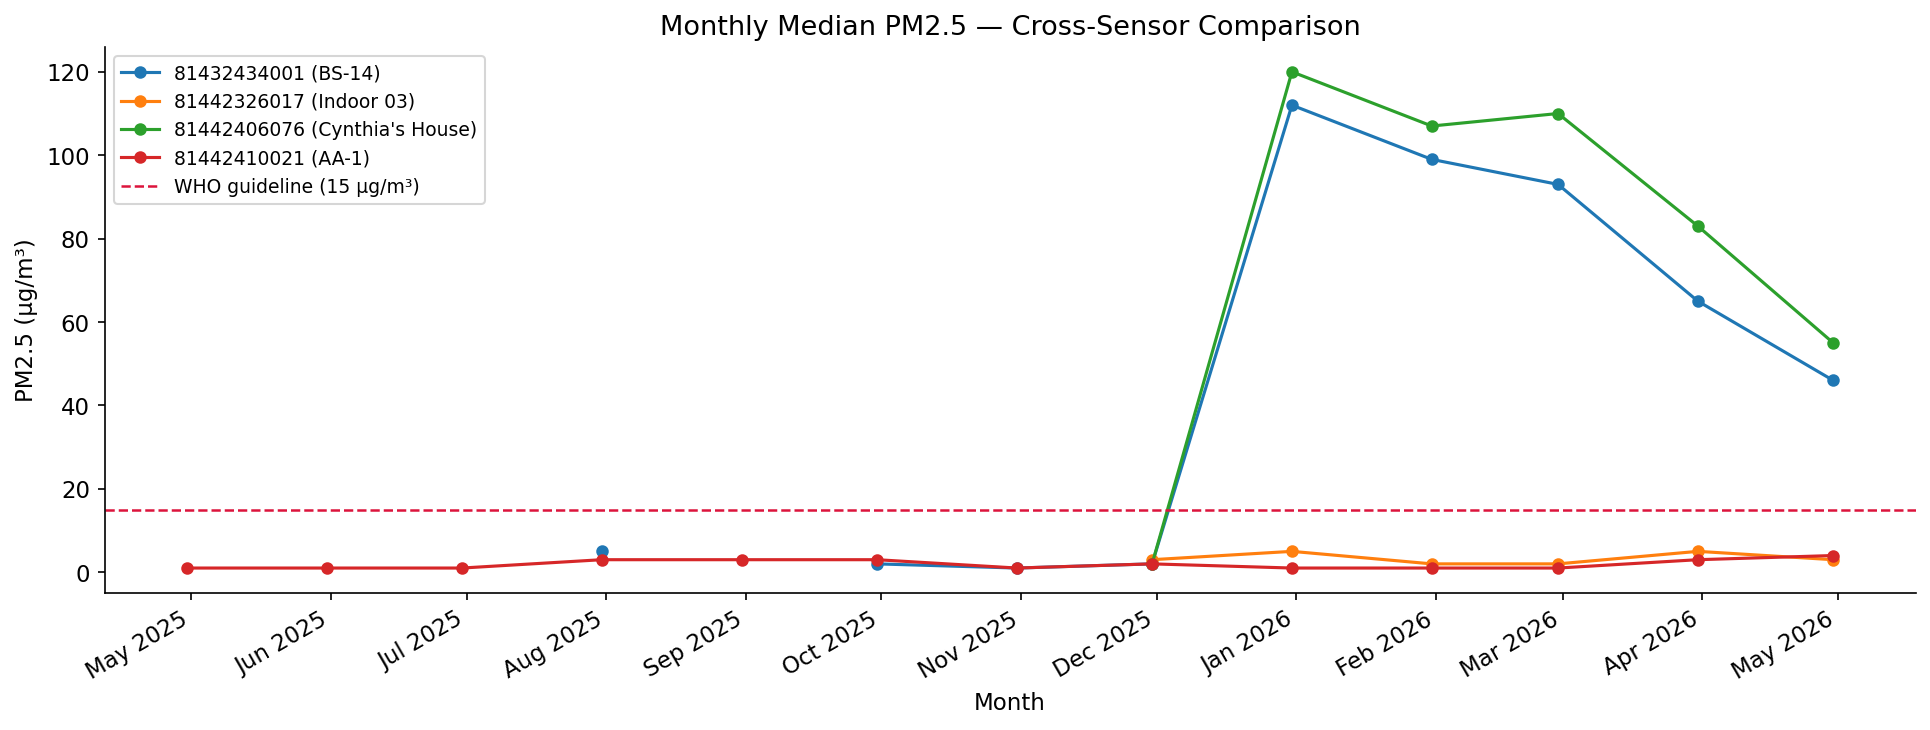

In [12]:
fig, ax = plt.subplots(figsize=(13, 5))

for i, serial in enumerate(serials):
    sub = all_df[all_df['serial'] == serial].set_index('timestamp')
    pm = pd.to_numeric(sub['pm25'], errors='coerce').resample('1ME').median()
    sensor_name = all_df[all_df['serial'] == serial]['name'].iloc[0]
    ax.plot(pm.index, pm.values, marker='o', ms=5, lw=1.5,
            color=colors[i], label=f'{serial} ({sensor_name})')

ax.axhline(WHO_PM25, color='crimson', lw=1.2, ls='--', label=f'WHO guideline ({WHO_PM25} µg/m³)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
plt.setp(ax.get_xticklabels(), rotation=30, ha='right')
ax.set_ylabel('PM2.5 (µg/m³)')
ax.set_xlabel('Month')
ax.set_title('Monthly Median PM2.5 — Cross-Sensor Comparison')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 12. Correlation Matrix (Hourly Medians — Sensor 81432434001)

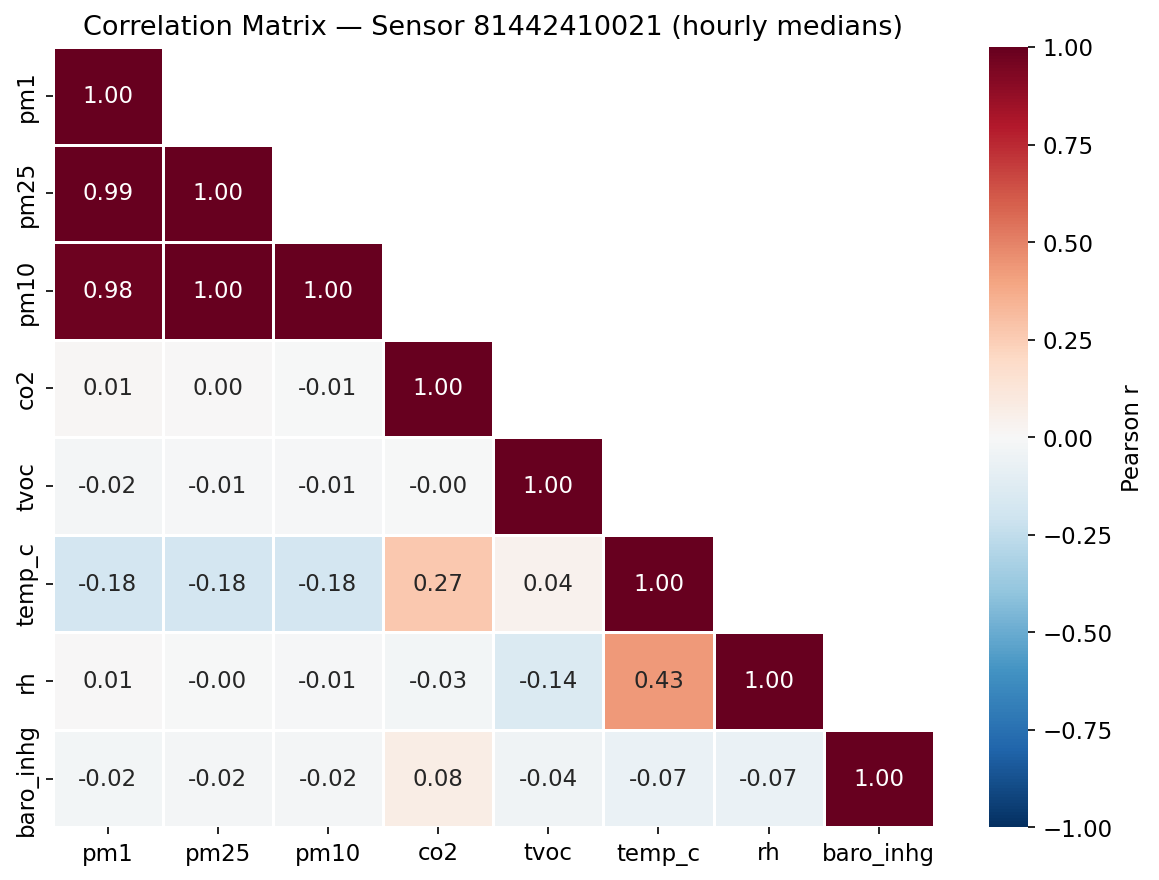

In [13]:
# Use sensor with most channels for correlation
best_serial = all_df.groupby('serial').size().idxmax()
sub = all_df[all_df['serial'] == best_serial].set_index('timestamp').copy()

corr_cols = [c for c in ['pm1','pm25','pm10','co2','tvoc','temp_c','rh','baro_inhg'] if c in sub.columns]
hourly = sub[corr_cols].apply(pd.to_numeric, errors='coerce').resample('1h').median()
corr = hourly.corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', vmin=-1, vmax=1,
            mask=mask, ax=ax, linewidths=0.5,
            cbar_kws={'label': 'Pearson r'})
ax.set_title(f'Correlation Matrix — Sensor {best_serial} (hourly medians)')
plt.tight_layout()
plt.show()

## 13. Descriptive Statistics

In [14]:
stat_cols = [c for c in ['pm1','pm25','pm10','pm25_aqi','pm10_aqi',
                          'co2','tvoc','temp_c','rh','baro_inhg'] if c in all_df.columns]

stats_frames = []
for serial in serials:
    sub = all_df[all_df['serial'] == serial][stat_cols].apply(pd.to_numeric, errors='coerce')
    desc = sub.describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).T
    desc.insert(0, 'serial', serial)
    stats_frames.append(desc)

stats_df = pd.concat(stats_frames)
display(stats_df.round(2))

,serial,count,mean,std,min,5%,25%,50%,75%,95%,max
pm1,81432434001,291588.0,58.49,88.41,0.00,0.00,2.00,34.00,90.00,182.00,5988.00
pm25,81432434001,291588.0,62.82,99.59,0.00,0.00,2.00,36.00,98.00,195.00,9468.00
pm10,81432434001,291588.0,64.03,108.74,0.00,0.00,2.00,36.00,100.00,197.00,13398.00
pm25_aqi,81432434001,291588.0,101.25,92.02,-1.00,0.00,8.00,97.00,172.00,237.00,500.00
pm10_aqi,81432434001,291588.0,43.81,50.66,-1.00,0.00,2.00,32.00,73.00,120.00,500.00
co2,81432434001,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tvoc,81432434001,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
temp_c,81432434001,291588.0,22.87,5.53,8.60,13.60,18.90,23.30,25.80,32.30,37.50
rh,81432434001,291588.0,56.09,15.49,17.00,33.00,42.00,59.00,70.00,77.00,86.00
baro_inhg,81432434001,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 14. Telemetry Files — Quick Inspection

The two telemetry files cover a narrower window but offer 1-minute resolution.

In [15]:
tele_files = sorted(DATA_ROOT.glob('*_telemetry.csv'))

tele_frames = []
for f in tele_files:
    df = pd.read_csv(f, low_memory=False)
    df['timestamp'] = pd.to_datetime(df['timestamp'], utc=True)
    df = df.rename(columns={'device_serial': 'serial'})
    print(f'{f.name}: {len(df):,} rows, {df["timestamp"].min().date()} → {df["timestamp"].max().date()}')
    print('  Columns:', list(df.columns))
    tele_frames.append(df)

tele_df = pd.concat(tele_frames, ignore_index=True)

81432434001_telemetry.csv: 113,092 rows, 2026-03-01 → 2026-05-19
  Columns: ['timestamp', 'device_model', 'serial', 'Fan Speed', 'N/A', 'NC 0.5', 'NC 1.0', 'NC 10', 'NC 2.5', 'NC 4.0', 'PM 1.0', 'PM 10', 'PM 10 AQI', 'PM 2.5', 'PM 2.5 AQI', 'PM 4.0', 'Relative Humidity', 'Temperature', 'Typical Particle Size']
81442406076_telemetry.csv: 67,085 rows, 2026-03-30 → 2026-05-19
  Columns: ['timestamp', 'device_model', 'serial', 'Barometric Pressure', 'Carbon Dioxide', 'N/A', 'NC 0.5', 'NC 1.0', 'NC 10', 'NC 2.5', 'NC 4.0', 'PM 1.0', 'PM 10', 'PM 10 AQI', 'PM 2.5', 'PM 2.5 AQI', 'PM 4.0', 'Relative Humidity', 'Temperature', 'Total VOC', 'Total VOC (ppb)', 'Typical Particle Size', 'VOC Index']


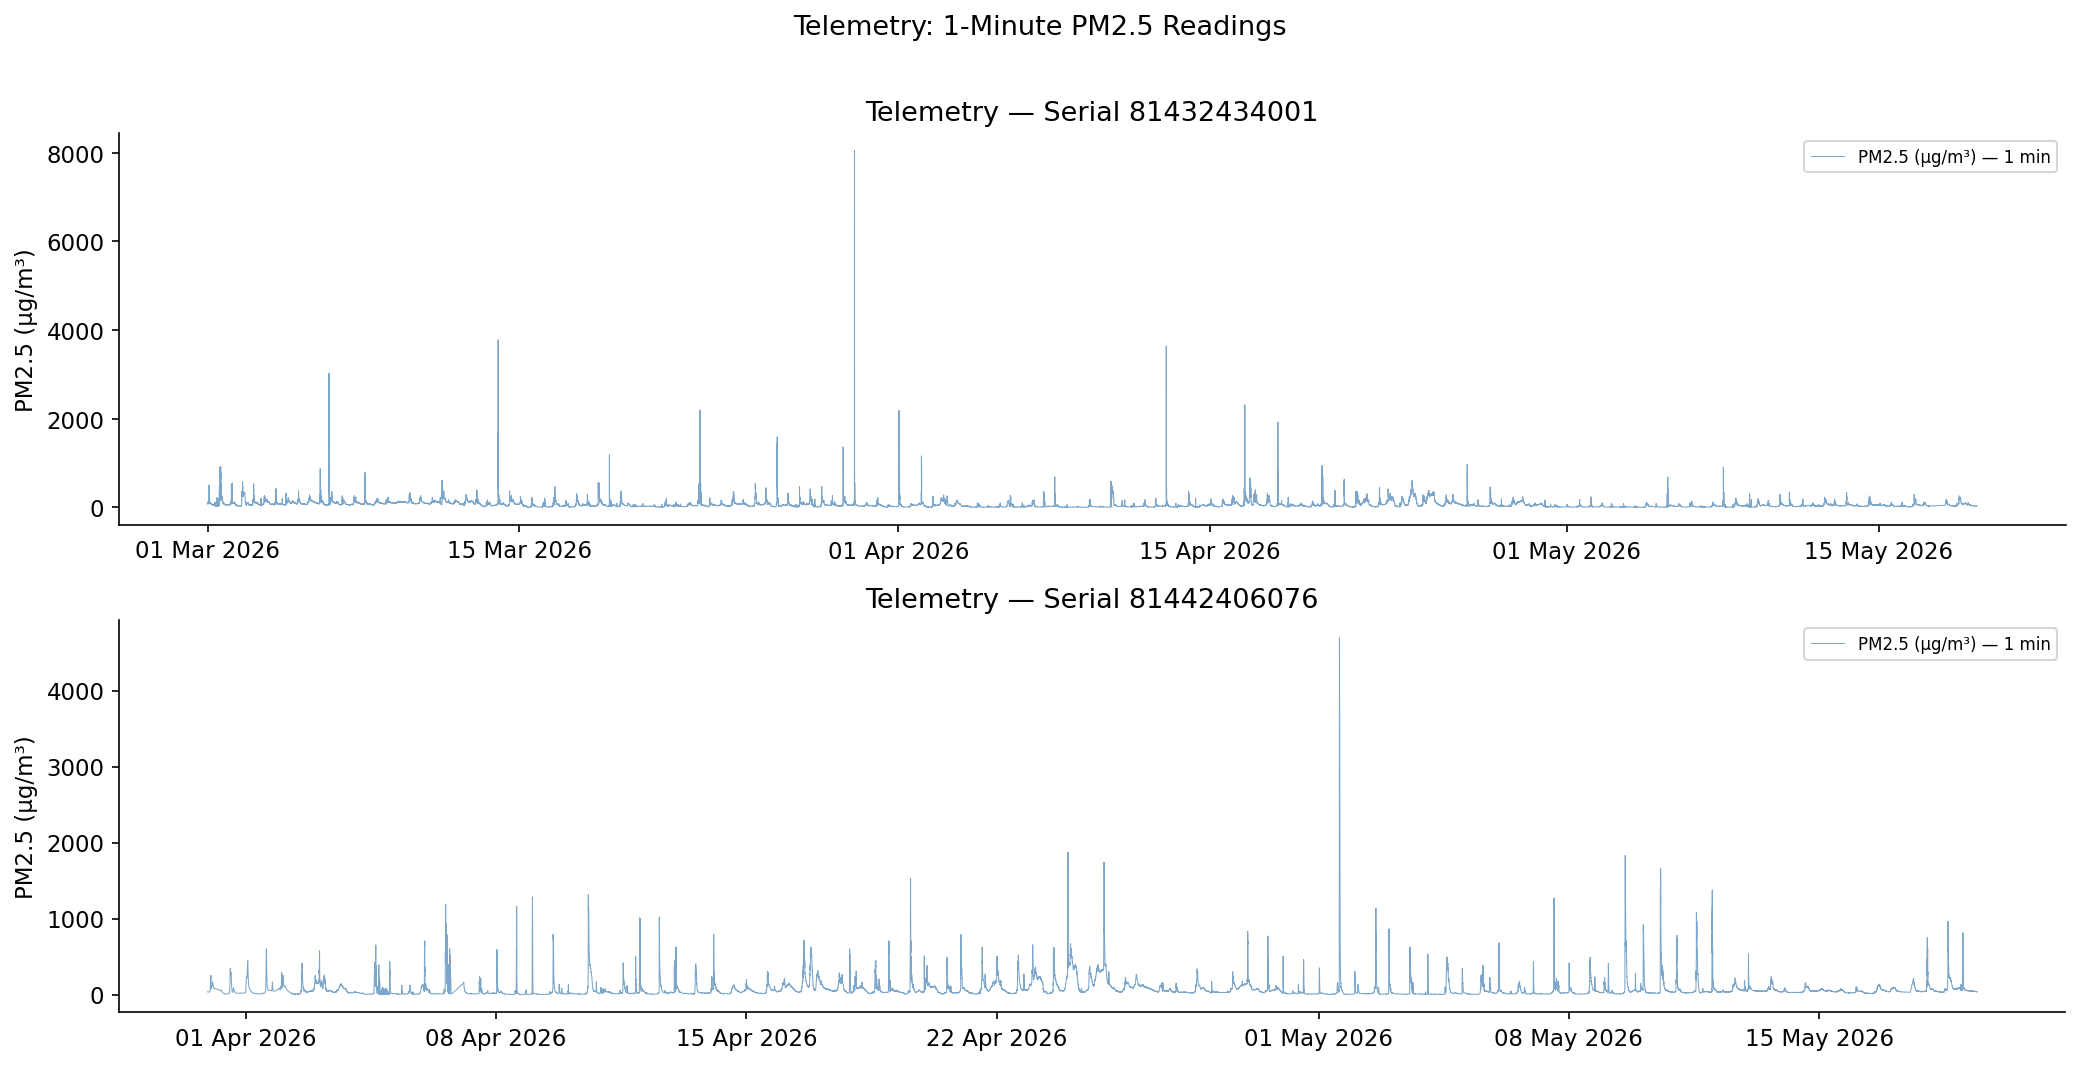

In [16]:
# Plot 1-min PM2.5 from telemetry for available serials
tele_serials = tele_df['serial'].unique()

fig, axes = plt.subplots(len(tele_serials), 1, figsize=(14, 3.5 * len(tele_serials)), sharex=False)
if len(tele_serials) == 1:
    axes = [axes]

for ax, serial in zip(axes, sorted(tele_serials)):
    sub = tele_df[tele_df['serial'] == serial].set_index('timestamp').sort_index()
    # PM columns differ by device
    pm_col = 'PM 2.5' if 'PM 2.5' in sub.columns else None
    if pm_col:
        pm = pd.to_numeric(sub[pm_col], errors='coerce')
        ax.plot(pm.index, pm.values, lw=0.5, color='steelblue', alpha=0.7, label='PM2.5 (µg/m³) — 1 min')
        ax.set_ylabel('PM2.5 (µg/m³)')
    else:
        ax.text(0.5, 0.5, 'PM2.5 column not found', transform=ax.transAxes, ha='center')
    ax.set_title(f'Telemetry — Serial {serial}')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b %Y'))
    ax.legend(fontsize=8)

fig.suptitle('Telemetry: 1-Minute PM2.5 Readings', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 15. Summary Statistics Table

In [17]:
summary_rows = []
for serial in serials:
    sub = all_df[all_df['serial'] == serial]
    pm25 = pd.to_numeric(sub['pm25'], errors='coerce')
    pm10 = pd.to_numeric(sub['pm10'], errors='coerce')
    temp = pd.to_numeric(sub['temp_c'], errors='coerce')
    rh_s = pd.to_numeric(sub['rh'], errors='coerce')
    co2_s = pd.to_numeric(sub['co2'], errors='coerce') if 'co2' in sub.columns else pd.Series(dtype=float)
    row = {
        'Serial': serial,
        'Name': sub['name'].iloc[0],
        'N (obs)': len(sub),
        'PM2.5 mean (µg/m³)': round(pm25.mean(), 1),
        'PM2.5 max (µg/m³)': round(pm25.max(), 1),
        'PM10 mean (µg/m³)': round(pm10.mean(), 1),
        'Temp mean (°C)': round(temp.mean(), 1),
        'RH mean (%)': round(rh_s.mean(), 1),
        'CO2 mean (ppm)': round(co2_s.mean(), 0) if co2_s.notna().any() else 'N/A',
        '% obs > WHO PM2.5': f"{(pm25 > 15).mean()*100:.1f}%",
    }
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows).set_index('Serial')
display(summary_df)

,Name,N (obs),PM2.5 mean (µg/m³),PM2.5 max (µg/m³),PM10 mean (µg/m³),Temp mean (°C),RH mean (%),CO2 mean (ppm),% obs > WHO PM2.5
Serial,,,,,,,,,
81432434001,BS-14,291588,62.8,9468,64.0,22.9,56.1,N/A,55.5%
81442326017,Indoor 03,5445,4.3,144,4.4,21.7,44.5,539.0,3.6%
81442406076,Cynthia's House,167188,146.2,8130,150.7,19.9,70.4,534.0,97.4%
81442410021,AA-1,376180,4.2,422,4.6,20.8,50.5,461.0,3.4%


---

## Data Summary

The Belauri deployment comprises **four air quality sensors** from the Sensirion SEN5x / SEN6x ecosystem (device models 8143 and 8144), operated by a research team at the Belauri site. Sensor **81432434001** ("BS-14", model 8143) is the primary outdoor unit with the longest continuous record, spanning July 2025 through mid-May 2026 (~113 k observations at ~1-min cadence in telemetry and ~291 k rows across its two periodic export files). The remaining three sensors — **81442326017** ("Indoor 03"), **81442406076** (unnamed / outdoor), and **81442410021** ("AA-1") — are model-8144 units that add CO2, total VOC (TVOC), formaldehyde (CH2O), CO, SO2, O3, and NO2 channels not available on the 8143. These three share a combined data package covering November 2024 through May 2026, though sensor 81442326017 started later (November 2025) while 81442410021 has data from April 2025. Together the dataset yields roughly **1 million raw records** (after deduplication). All four sensors report PM1.0, PM2.5, PM4.0, PM10 (µg/m³), number concentrations (NC) for five size bins (#/cm³), typical particle size, temperature (°C), and relative humidity (%). PM2.5 concentrations at the site frequently exceed the WHO 2021 annual guideline of 15 µg/m³, particularly in the indoor/enclosed sensor locations, underscoring the relevance of continued monitoring.